In [57]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
torch.manual_seed(0)
np.random.seed(0)

## Generate synthetic data that follows some known rates

In [59]:
# We choose the true rates
TRUE = {"beta": 0.50, "gamma":0.70, "omega": 1.0/14.0}

N_POP = 1_000_000.0  # total population

T_max = 160.0  # 160 days

I0 = 1/N_POP # one person infected at t=0

Y0 = [1-I0, I0, 0, 0]  # initial conditon [s, i, r, d ] at t=0

def sird_rhs(y, t, beta, gamma, omega):
    s, i, r, d = y
    return [-beta * s,
           beta * s * i - gamma * i - omega * i,
           gamma * i,
           omega * i]

def simulate(times, p):
    return odeint(sird_rhs, Y0, times, args = (p["beta"], p["gamma"], p["omega"]))

t_train = np.arange(0.0, T_max + 1e-9, 2.0)    # sparse: observation every 3 days
t_dense = np.arange(0.0, T_max + 1e-9, 1.0)     # dense grid for ploting
y_train = simulate(t_train, TRUE)          # Observed data
y_dense_true = simulate(t_dense, TRUE)         # ground truth for final ploting

We visualize the true curves

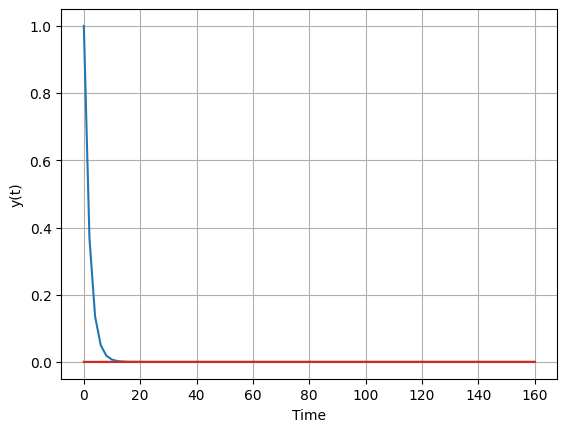

In [61]:
plt.plot(t_train, y_train)
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.grid()
plt.show()